# 09 - Build CJEU → EC Network & First Analysis

This notebook builds a bipartite directed network between CJEU documents and EC antitrust cases,
and performs a focused first analysis using only the most interpretable metrics for this network type.

**Input:** `data/processed/cjeu_ec_case_matches.csv`

**Output:**
- `data/processed/network/cjeu_ec_nodes.csv`
- `data/processed/network/cjeu_ec_edges.csv`
- `data/processed/network/cjeu_ec_network.graphml`
- `data/processed/network/cjeu_ec_network.gexf`
- `data/processed/network/cjeu_ec_node_metrics.csv`

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/processed")
INPUT_PATH = DATA_DIR / "cjeu_ec_case_matches.csv"

OUT_DIR           = DATA_DIR / "network" / "cjeu_ec"
NODES_PATH        = OUT_DIR / "cjeu_ec_nodes.csv"
EDGES_PATH        = OUT_DIR / "cjeu_ec_edges.csv"
GRAPHML_PATH      = OUT_DIR / "cjeu_ec_network.graphml"
NODE_METRICS_PATH = OUT_DIR / "cjeu_ec_node_metrics.csv"

FIGURES_DIR = Path("outputs/figures/cjeu_ec")

# Match-strength ordering (higher index = stronger)
STRENGTH_ORDER = {"weak": 0, "medium": 1, "strong": 2}

print("Configuration loaded.")

Configuration loaded.


## 2. Load CSV

In [2]:
df = pd.read_csv(INPUT_PATH, dtype=str).fillna("")

print(f"Rows loaded : {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Rows loaded : 859
Columns     : ['cjeu_celex_id', 'cjeu_cellar_id', 'cjeu_title', 'cjeu_document_date', 'ec_case_number', 'ec_case_title', 'ec_celex_no', 'matched_pattern', 'matched_text', 'match_strength', 'match_context', 'document_source_url', 'document_format', 'processing_status']


,cjeu_celex_id,cjeu_cellar_id,cjeu_title,cjeu_document_date,ec_case_number,ec_case_title,ec_celex_no,matched_pattern,matched_text,match_strength,match_context,document_source_url,document_format,processing_status
0,62000CO0241,e5c51775-cb8c-4db5-8f62-cd29e5a9e83d,,2001-10-18,IV/34193,Kish Glass,,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/34.193,medium,Kish Glass v Commission [2000] ECR II-1885 (he...,https://publications.europa.eu/resource/celex/...,html_eng,matched
1,61989TO0030,df2aaabf-51bf-4e05-947a-c7df2deae637,,1990-04-04,IV/30787; IV/31488,EUROFIX -BAUCO / HILTI,31988D0138,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/30.787,medium,"egal Department, Wagner Centre, Kirchberg, def...",https://publications.europa.eu/resource/celex/...,html_eng,matched
2,61992TO0074,2cbd70fe-2eb3-4d0e-97d8-827bb97f9440,,1993-05-13,IV/33375,PMI-DSV,31995D0373,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/33.375,medium,n its complaint which has given rise to a proc...,https://publications.europa.eu/resource/celex/...,html_eng,matched


## 3. Filter: Only Real Matches

In [3]:
# Keep only rows with processing_status == "matched"
matched = df[df["processing_status"] == "matched"].copy()

# Drop rows with empty CJEU or EC identifiers
matched = matched[
    matched["cjeu_celex_id"].str.strip().ne("") &
    matched["ec_case_number"].str.strip().ne("")
].copy()

print(f"Rows after filtering: {len(matched):,}")

Rows after filtering: 859


## 4. Deduplicate to One Edge per CJEU-EC Pair

In [4]:
def best_strength(strengths: pd.Series) -> str:
    """Return the strongest match_strength value in a group."""
    ranked = strengths.map(lambda s: STRENGTH_ORDER.get(s, -1))
    best_idx = ranked.idxmax()
    return strengths.loc[best_idx]


edges_raw = (
    matched
    .groupby(["cjeu_celex_id", "ec_case_number"], sort=False)
    .agg(
        match_count           = ("match_strength", "count"),
        best_match_strength   = ("match_strength", best_strength),
        all_match_strengths   = ("match_strength", lambda s: "|".join(s.unique())),
        example_match_context = ("match_context", "first"),
    )
    .reset_index()
)

print(f"Unique CJEU-EC pairs (edges): {len(edges_raw):,}")
edges_raw.head(3)

Unique CJEU-EC pairs (edges): 859


,cjeu_celex_id,ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,62000CO0241,IV/34193,1,medium,medium,Kish Glass v Commission [2000] ECR II-1885 (he...
1,61989TO0030,IV/30787; IV/31488,1,medium,medium,"egal Department, Wagner Centre, Kirchberg, def..."
2,61992TO0074,IV/33375,1,medium,medium,n its complaint which has given rise to a proc...


## 5. Build Node Tables

In [5]:
# ── A. CJEU nodes ──────────────────────────────────────────────────────────────
cjeu_meta = (
    matched[["cjeu_celex_id", "cjeu_title", "cjeu_document_date"]]
    .drop_duplicates(subset="cjeu_celex_id")
    .copy()
)

cjeu_nodes = pd.DataFrame({
    "node_id"  : "cjeu:" + cjeu_meta["cjeu_celex_id"],
    "node_type": "cjeu",
    "label"    : cjeu_meta["cjeu_title"].values,
    "celex_id" : cjeu_meta["cjeu_celex_id"].values,
    "date"     : cjeu_meta["cjeu_document_date"].values,
})

print(f"CJEU nodes: {len(cjeu_nodes):,}")
cjeu_nodes.head(3)

CJEU nodes: 505


,node_id,node_type,label,celex_id,date
0,cjeu:62000CO0241,cjeu,,62000CO0241,2001-10-18
1,cjeu:61989TO0030,cjeu,,61989TO0030,1990-04-04
2,cjeu:61992TO0074,cjeu,,61992TO0074,1993-05-13


In [6]:
# ── B. EC nodes ────────────────────────────────────────────────────────────────
ec_meta = (
    matched[["ec_case_number", "ec_case_title", "ec_celex_no"]]
    .drop_duplicates(subset="ec_case_number")
    .copy()
)

ec_nodes = pd.DataFrame({
    "node_id"    : "ec:" + ec_meta["ec_case_number"],
    "node_type"  : "ec",
    "label"      : ec_meta["ec_case_title"].values,
    "case_number": ec_meta["ec_case_number"].values,
    "celex_no"   : ec_meta["ec_celex_no"].values,
})

print(f"EC nodes: {len(ec_nodes):,}")
ec_nodes.head(3)

EC nodes: 248


,node_id,node_type,label,case_number,celex_no
0,ec:IV/34193,ec,Kish Glass,IV/34193,
1,ec:IV/30787; IV/31488,ec,EUROFIX -BAUCO / HILTI,IV/30787; IV/31488,31988D0138
2,ec:IV/33375,ec,PMI-DSV,IV/33375,31995D0373


## 6. Build Edge Table

In [7]:
edges = edges_raw.copy()
edges.insert(0, "source", "cjeu:" + edges["cjeu_celex_id"])
edges.insert(1, "target", "ec:"   + edges["ec_case_number"])

print(f"Edges: {len(edges):,}")
edges.head(3)

Edges: 859


,source,target,cjeu_celex_id,ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,cjeu:62000CO0241,ec:IV/34193,62000CO0241,IV/34193,1,medium,medium,Kish Glass v Commission [2000] ECR II-1885 (he...
1,cjeu:61989TO0030,ec:IV/30787; IV/31488,61989TO0030,IV/30787; IV/31488,1,medium,medium,"egal Department, Wagner Centre, Kirchberg, def..."
2,cjeu:61992TO0074,ec:IV/33375,61992TO0074,IV/33375,1,medium,medium,n its complaint which has given rise to a proc...


## 7. Build NetworkX Bipartite Graph

In [8]:
G = nx.DiGraph()

# Node colour constants
COLOR_CJEU = "#4C72B0"
COLOR_EC   = "#DD8452"

# Add CJEU nodes
for _, row in cjeu_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type="cjeu",
        node_color=COLOR_CJEU,
        label=row["label"],
        celex_id=row["celex_id"],
        date=row["date"],
        bipartite=0,
    )

# Add EC nodes
for _, row in ec_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type="ec",
        node_color=COLOR_EC,
        label=row["label"],
        case_number=row["case_number"],
        celex_no=row["celex_no"],
        bipartite=1,
    )

# Add edges
for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        match_count=int(row["match_count"]),
        best_match_strength=row["best_match_strength"],
        all_match_strengths=row["all_match_strengths"],
        example_match_context=str(row["example_match_context"])[:300],
    )

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph: 753 nodes, 859 edges


## 8. Basic Statistics

In [9]:
print(f"CJEU nodes : {len(cjeu_nodes):,}")
print(f"EC nodes   : {len(ec_nodes):,}")
print(f"Edges      : {len(edges):,}")

CJEU nodes : 505
EC nodes   : 248
Edges      : 859


---
## 8A. Structure Overview

This bar chart shows the number of CJEU source nodes, EC target nodes, and directed citation edges in the network.
It gives a quick structural summary of the bipartite graph before any deeper analysis.

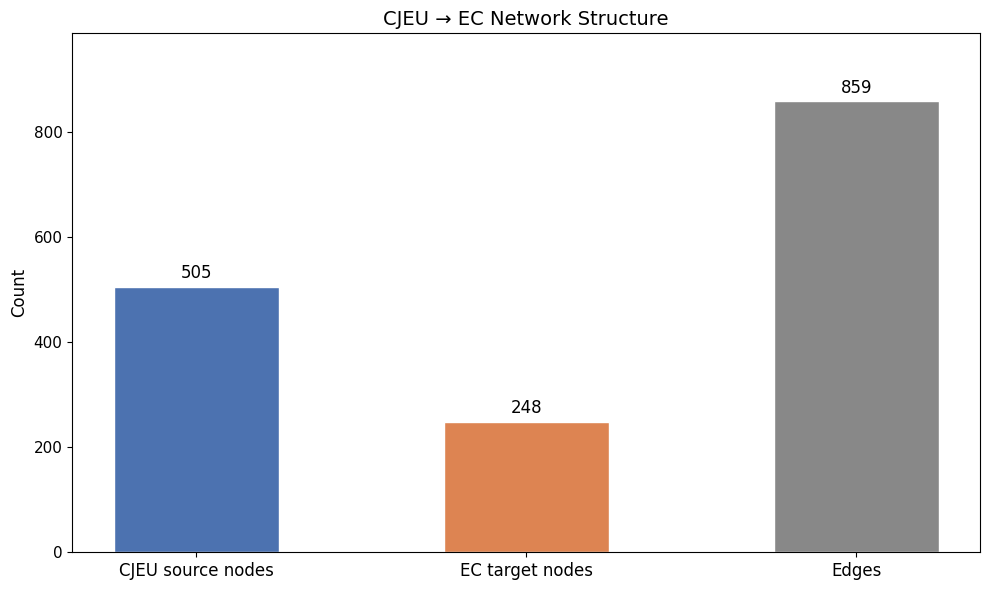

Saved fig_cjeu_ec_structure_overview.png


In [10]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})

struct_labels  = ["CJEU source nodes", "EC target nodes", "Edges"]
struct_values  = [len(cjeu_nodes), len(ec_nodes), len(edges)]
struct_colors  = [COLOR_CJEU, COLOR_EC, "#888888"]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
bars = ax.bar(struct_labels, struct_values, color=struct_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, struct_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(struct_values) * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=12, color="black")
ax.set_title("CJEU → EC Network Structure", fontsize=14, color="black")
ax.set_ylabel("Count", fontsize=12, color="black")
ax.set_ylim(0, max(struct_values) * 1.15)
ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_structure_overview.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_structure_overview.png")

---
## 9. Weakly Connected Components

**What it measures:**
A weakly connected component (WCC) is a maximal set of nodes such that every node can reach
every other node if edge directions are ignored. In other words, two nodes belong to the same
WCC if there is an undirected path between them.

**Why it matters for this CJEU → EC citation network:**
Because this is a bipartite directed graph (CJEU documents only cite EC cases, never the reverse),
strongly connected components are trivial (each node is its own SCC). Weakly connected components
are therefore the most informative connectivity measure: they reveal whether the network forms one
large connected cluster or splits into several isolated sub-networks of CJEU documents and EC cases.

A large dominant WCC means most CJEU documents and EC cases are structurally linked through the
citation graph, while small isolated components may indicate niche or peripheral citation clusters.

In [11]:
wccs = list(nx.weakly_connected_components(G))
wccs_sorted = sorted(wccs, key=len, reverse=True)

print(f"Number of weakly connected components : {len(wccs_sorted):,}")
print(f"Largest WCC size                       : {len(wccs_sorted[0]):,} nodes")
print(f"Nodes in largest WCC (% of total)      : {len(wccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")

# Summary table of component sizes
wcc_summary = pd.DataFrame({
    "component_id"  : range(1, len(wccs_sorted) + 1),
    "size"          : [len(c) for c in wccs_sorted],
})

print("\nWeakly connected component sizes (top 20):")
display(wcc_summary.head(20))

Number of weakly connected components : 71
Largest WCC size                       : 531 nodes
Nodes in largest WCC (% of total)      : 70.5%

Weakly connected component sizes (top 20):


,component_id,size
0,1,531
1,2,9
2,3,9
3,4,8
4,5,8
5,6,8
6,7,7
7,8,6
8,9,6
9,10,5


### 9A. WCC Size Distribution

This bar chart shows how many weakly connected components exist at each size.
Most components are small (isolated pairs or tiny clusters); the dominant component contains the bulk of the network.

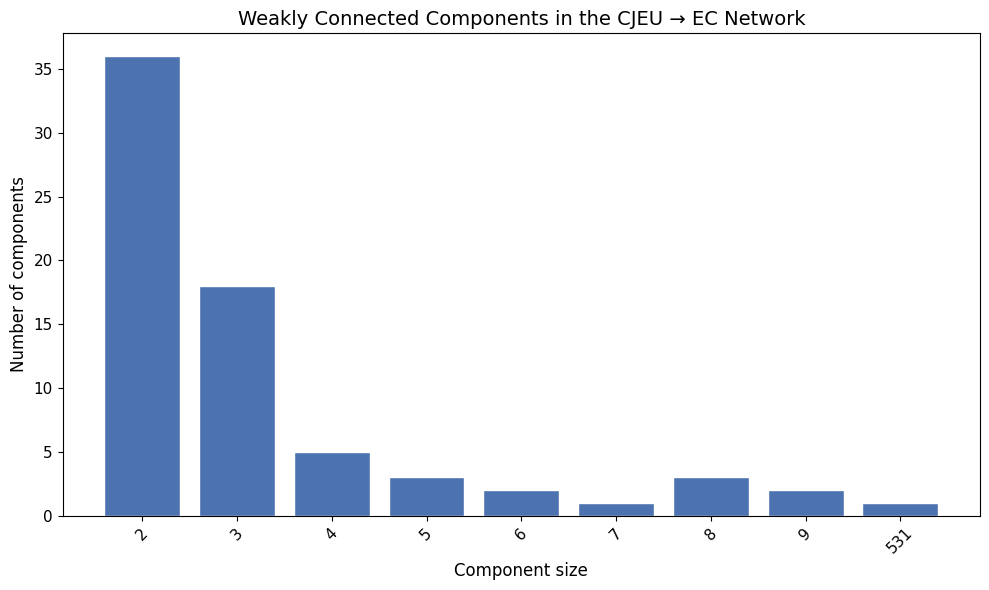

Saved fig_cjeu_ec_wcc_distribution.png


In [12]:
size_counts = wcc_summary["size"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
ax.bar(size_counts.index.astype(str), size_counts.values, color="#4C72B0", edgecolor="white")
ax.set_title("Weakly Connected Components in the CJEU → EC Network", fontsize=14, color="black")
ax.set_xlabel("Component size", fontsize=12, color="black")
ax.set_ylabel("Number of components", fontsize=12, color="black")
ax.tick_params(axis="x", labelrotation=45, labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_wcc_distribution.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_wcc_distribution.png")

### 9B. Edges per Year

This chart shows the number of CJEU → EC citation edges per year, based on the document date of the citing CJEU document.
It reveals how citation activity has evolved over time.

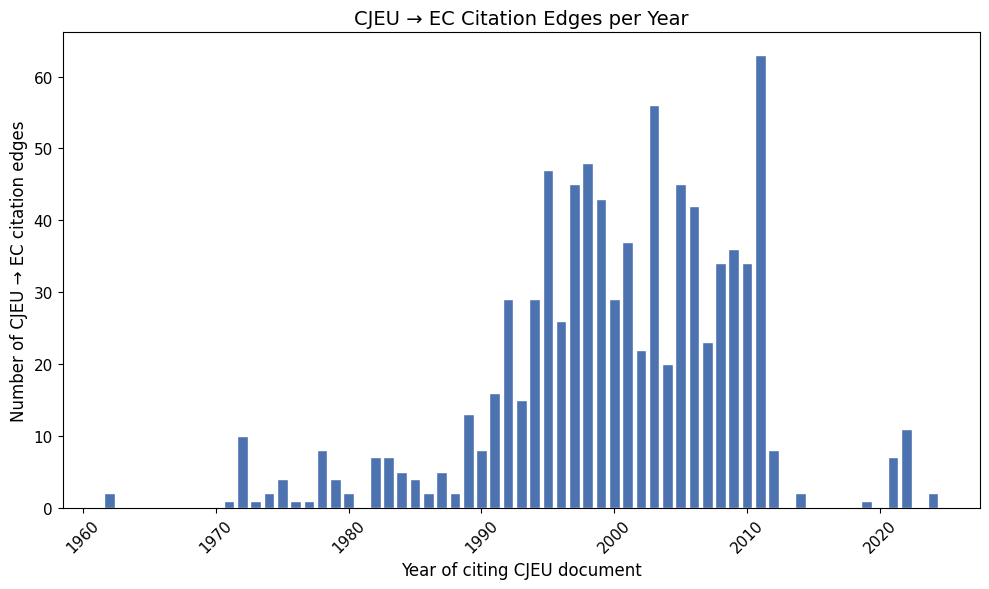

Saved fig_cjeu_ec_edges_per_year.png


In [13]:
# Merge year from cjeu_nodes into edges via source node id
cjeu_year = cjeu_nodes[["node_id", "date"]].copy()
cjeu_year["year"] = pd.to_datetime(cjeu_year["date"], errors="coerce").dt.year
edges_year = edges.merge(cjeu_year[["node_id", "year"]], left_on="source", right_on="node_id", how="left")

edges_per_year = (
    edges_year.dropna(subset=["year"])
    .groupby("year")["source"]
    .count()
    .rename("edge_count")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
ax.bar(edges_per_year.index.astype(int), edges_per_year.values, color="#4C72B0", edgecolor="white")
ax.set_title("CJEU → EC Citation Edges per Year", fontsize=14, color="black")
ax.set_xlabel("Year of citing CJEU document", fontsize=12, color="black")
ax.set_ylabel("Number of CJEU → EC citation edges", fontsize=12, color="black")
ax.tick_params(axis="x", labelrotation=45, labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_edges_per_year.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_edges_per_year.png")

## 10. Visualisation (Top 50 Nodes)

A quick visual impression of the network using the 25 most-cited EC cases and the 25 most-citing CJEU documents.

Subgraph: 50 nodes, 68 edges


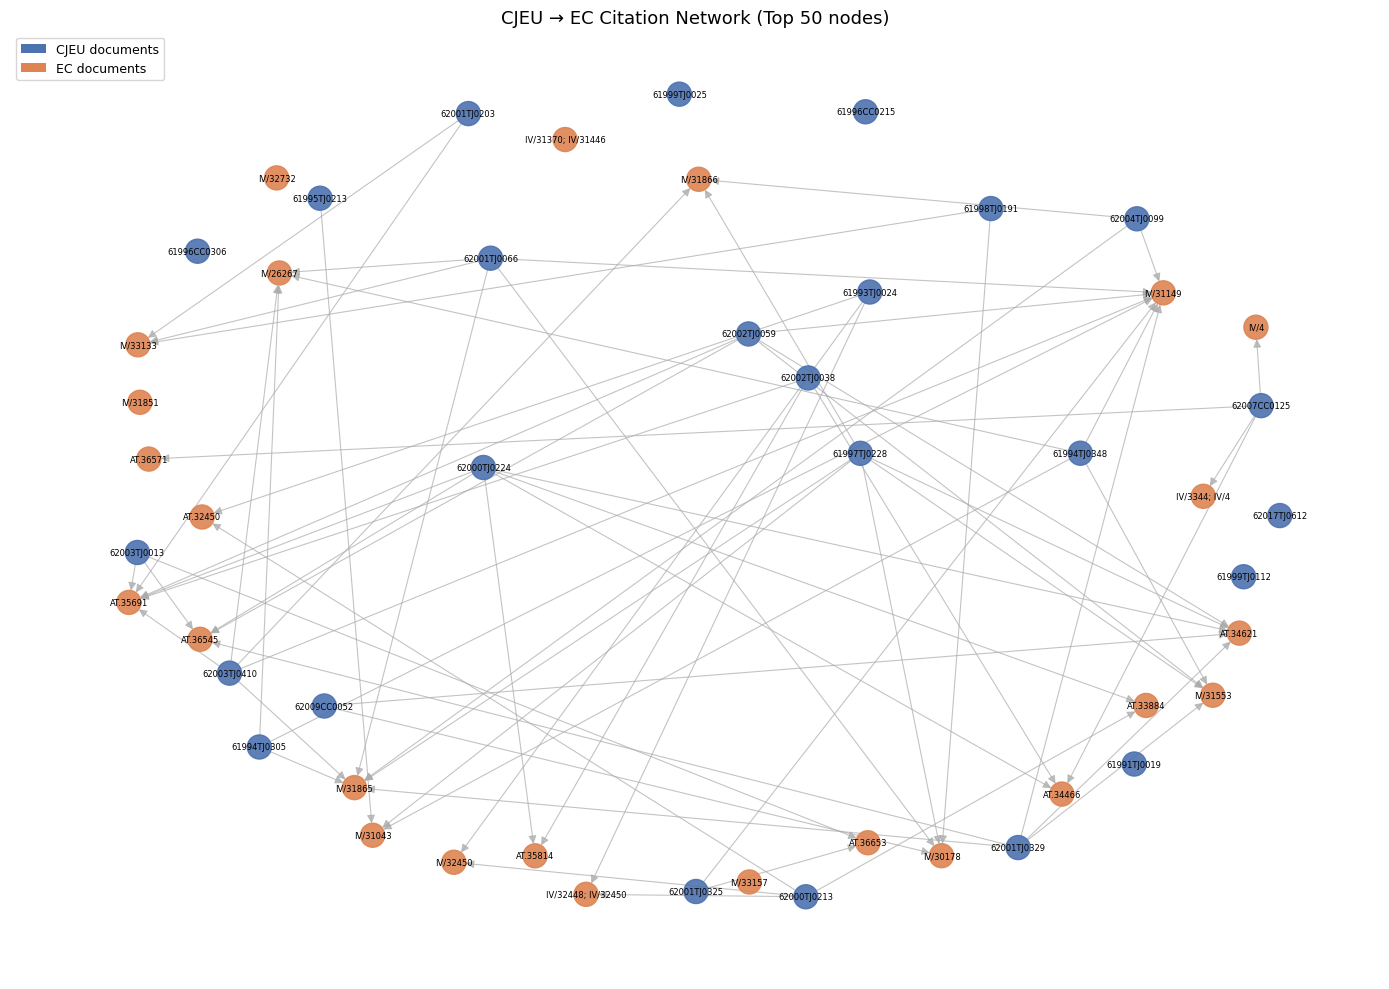

In [14]:
from matplotlib.patches import Patch

# Pre-compute degree series for subgraph selection
in_deg_series = pd.Series(
    {n: d for n, d in G.in_degree() if G.nodes[n]["node_type"] == "ec"},
    name="in_degree",
).sort_values(ascending=False)

out_deg_series = pd.Series(
    {n: d for n, d in G.out_degree() if G.nodes[n]["node_type"] == "cjeu"},
    name="out_degree",
).sort_values(ascending=False)

# Select the 25 most-cited EC nodes and 25 most-citing CJEU nodes
top_ec_ids   = in_deg_series.head(25).index.tolist()
top_cjeu_ids = out_deg_series.head(25).index.tolist()

sub_nodes = set(top_ec_ids) | set(top_cjeu_ids)
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

# Node colours (read from graph attribute)
color_map = [H.nodes[n]["node_color"] for n in H.nodes()]

# Short labels
labels = {}
for n in H.nodes():
    attrs = H.nodes[n]
    if attrs["node_type"] == "cjeu":
        labels[n] = attrs.get("celex_id", n)
    else:
        labels[n] = attrs.get("case_number", n)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=1.5)

nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_elements = [
    Patch(facecolor=COLOR_CJEU, label="CJEU documents"),
    Patch(facecolor=COLOR_EC,   label="EC documents"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("CJEU → EC Citation Network (Top 50 nodes)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 11. Network Analysis

The sections below compute the core node metrics for this bipartite directed graph.
Only the most interpretable metrics for a CJEU → EC citation network are included:
**in-degree**, **out-degree**, and **PageRank**.

> **Note on edge attributes** (`match_count`, `best_match_strength`):
> These describe how well a CJEU document matches an EC case (number of matching passages,
> strongest match type). They are not centrality measures and are not used in the computations
> below, but remain available for filtering or weighting in future analyses.

### 11.1 In-Degree and Out-Degree

**What it measures:**
- **In-degree** = number of incoming edges → how often a node is *cited*.
- **Out-degree** = number of outgoing edges → how many citations a node *makes*.

**Why it matters for this citation network:**
In-degree is the simplest and most direct proxy for the importance of an EC case:
the more CJEU documents cite it, the more influential it is.
Out-degree shows which CJEU documents are the most prolific citers of EC antitrust cases.

**Most meaningful for:**
- In-degree → **EC nodes** (which cases are most cited by CJEU)
- Out-degree → **CJEU nodes** (which documents cite the most EC cases)

In [15]:
# Compute in- and out-degree for every node
in_degree_all  = dict(G.in_degree())
out_degree_all = dict(G.out_degree())

# ── Top cited EC cases (by in-degree) ─────────────────────────────────────────
ec_in = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)

print("Top 20 most cited EC cases (in-degree):")
display(ec_in.head(20))
# ── CJEU label helpers ────────────────────────────────────────────────────────
import re as _re
def _derive_case_number_from_celex(celex_id):
    """Derive readable case number from CELEX ID, e.g. 62012CJ0348 -> C-348/12"""
    m = _re.match(r'^6(\d{4})(CJ|CC|CO|TJ|TC|TO|FJ|FC|FO)(\d+)$', str(celex_id).strip())
    if m:
        year, proc, num = m.group(1), m.group(2), m.group(3)
        short = year[-2:]
        prefix = 'T' if proc in ('TJ','TC','TO') else ('F' if proc in ('FJ','FC','FO') else 'C')
        return f"{prefix}-{int(num)}/{short}"
    return ""

def _make_cjeu_label(r):
    cx      = str(r.get("celex_id", "")).strip()
    lbl     = str(r.get("label",    "")).strip()
    node_id = str(r.name)
    if lbl and not lbl.startswith("6") and lbl != cx:
        return lbl
    derived = _derive_case_number_from_celex(cx)
    if derived:
        return derived
    if cx:
        return cx
    return node_id


Top 20 most cited EC cases (in-degree):


,case_number,label,in_degree
node_id,,,
ec:IV/31149,IV/31149,POLYPROPYLENE,62
ec:IV/31865,IV/31865,PVC,35
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,26
ec:IV/31553,IV/31553,Welded Steel Mesh,21
ec:IV/3344; IV/4,IV/3344; IV/4,Grundig-Consten,20
ec:IV/4,IV/4,GRUNDIG,20
ec:AT.34466,AT.34466,Greek Ferries,16
ec:IV/33133,IV/33133,Soda-ash - ICI,15
ec:AT.35814,AT.35814,Extra d'alliage,14


In [16]:
# ── Top citing CJEU documents (by out-degree) ─────────────────────────────────
cjeu_out = (
    cjeu_nodes.set_index("node_id")[["celex_id", "label", "date"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)

print("Top 20 most citing CJEU documents (out-degree):")
display(cjeu_out.head(20))

Top 20 most citing CJEU documents (out-degree):


,celex_id,label,date,out_degree
node_id,,,,
cjeu:61998TJ0191,61998TJ0191,,2003-09-30,11
cjeu:61991TJ0019,61991TJ0019,,1992-02-27,11
cjeu:61997TJ0228,61997TJ0228,,1999-10-07,11
cjeu:62002TJ0038,62002TJ0038,,2005-10-25,8
cjeu:61995TJ0213,61995TJ0213,,1997-10-22,8
cjeu:61993TJ0024,61993TJ0024,,1996-10-08,8
cjeu:62000TJ0224,62000TJ0224,,2003-07-09,8
cjeu:62000TJ0213,62000TJ0213,,2003-03-19,7
cjeu:62007CC0125,62007CC0125,,2009-03-26,7


### 11.2 PageRank

**What it measures:**
PageRank assigns a score to each node based on the number and quality of incoming links.
A node receives a higher score if it is cited by nodes that are themselves highly cited.

**Why it matters for this citation network:**
Unlike raw in-degree, PageRank accounts for the *prestige* of the citing document.
An EC case cited by many influential CJEU judgments will rank higher than one cited
by less prominent documents.

**Most meaningful for:** **EC nodes** — identifies the most *prestigious* EC cases in the network.

> **Bipartite note:** PageRank is well-defined on directed graphs regardless of bipartiteness.
> CJEU nodes also receive a score, but the primary interpretation is for EC nodes.

In [17]:
pagerank = nx.pagerank(G, alpha=0.85)

# Top EC cases by PageRank
ec_pr = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
)

print("Top 20 EC cases by PageRank:")
display(ec_pr.head(20))

Top 20 EC cases by PageRank:


,case_number,label,in_degree,pagerank
node_id,,,,
ec:IV/31149,IV/31149,POLYPROPYLENE,62,0.033064
ec:IV/31865,IV/31865,PVC,35,0.015453
ec:IV/31553,IV/31553,Welded Steel Mesh,21,0.012915
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,26,0.011556
ec:IV/33133,IV/33133,Soda-ash - ICI,15,0.008757
ec:AT.34466,AT.34466,Greek Ferries,16,0.007776
ec:AT.35814,AT.35814,Extra d'alliage,14,0.007554
ec:IV/3344; IV/4,IV/3344; IV/4,Grundig-Consten,20,0.006818
ec:IV/4,IV/4,GRUNDIG,20,0.006818


---
## 12. Node-Level Metric Summary Table

All three core metrics are combined into a single node-level table for easy inspection and export.
Each row represents one node (CJEU document or EC case) with its `in_degree`, `out_degree`, and `pagerank`.

In [18]:
all_nodes = pd.concat([cjeu_nodes, ec_nodes], ignore_index=True)

node_metrics = all_nodes[["node_id", "node_type", "label"]].copy()

node_metrics["in_degree"]  = node_metrics["node_id"].map(in_degree_all)
node_metrics["out_degree"] = node_metrics["node_id"].map(out_degree_all)
node_metrics["pagerank"]   = node_metrics["node_id"].map(pagerank)

print(f"Node metrics table: {len(node_metrics):,} rows")
display(node_metrics.head(20))

Node metrics table: 753 rows


,node_id,node_type,label,in_degree,out_degree,pagerank
0,cjeu:62000CO0241,cjeu,,0,1,0.000846
1,cjeu:61989TO0030,cjeu,,0,1,0.000846
2,cjeu:61992TO0074,cjeu,,0,1,0.000846
3,cjeu:62000TO0059,cjeu,,0,1,0.000846
4,cjeu:61972CO0006,cjeu,,0,1,0.000846
5,cjeu:61976CO0027,cjeu,,0,1,0.000846
6,cjeu:61996TO0065,cjeu,,0,1,0.000846
7,cjeu:61993TO0024,cjeu,,0,3,0.000846
8,cjeu:62001TJ0289,cjeu,,0,1,0.000846
9,cjeu:62010CJ0110,cjeu,,0,1,0.000846


---
## 12A. Metric Summary Statistics and Distributions

This section provides summary statistics and distribution plots for all node-level metrics
computed in this notebook. Statistics are based on **all nodes** of the respective node group
(EC targets and CJEU sources), not just the top-10 rankings.

**Metrics covered:**
- `in_degree` → EC target nodes (how often each EC case is cited by CJEU documents)
- `out_degree` → CJEU source nodes (how many EC cases each CJEU document cites)
- `pagerank` → all nodes (prestige-weighted citation score)

In [19]:
from scipy import stats as _scipy_stats

SUMMARY_STATS_PATH = OUT_DIR / "cjeu_ec_metric_summary_stats.csv"

def _summary_stats(series: pd.Series, name: str) -> dict:
    """Compute summary statistics for a numeric series."""
    s = series.dropna()
    return {
        "metric"  : name,
        "count"   : int(s.count()),
        "mean"    : round(float(s.mean()), 6),
        "std"     : round(float(s.std()), 6),
        "min"     : round(float(s.min()), 6),
        "25%"     : round(float(s.quantile(0.25)), 6),
        "median"  : round(float(s.median()), 6),
        "75%"     : round(float(s.quantile(0.75)), 6),
        "max"     : round(float(s.max()), 6),
        "skewness": round(float(_scipy_stats.skew(s)), 4),
        "kurtosis": round(float(_scipy_stats.kurtosis(s)), 4),
    }

# ── EC nodes: in_degree ───────────────────────────────────────────────────────
ec_in_degree_series = pd.Series(
    {nid: in_degree_all[nid] for nid in ec_nodes["node_id"] if nid in in_degree_all},
    name="in_degree"
)

# ── CJEU nodes: out_degree ────────────────────────────────────────────────────
cjeu_out_degree_series = pd.Series(
    {nid: out_degree_all[nid] for nid in cjeu_nodes["node_id"] if nid in out_degree_all},
    name="out_degree"
)

# ── EC nodes: pagerank ────────────────────────────────────────────────────────
ec_pagerank_series = pd.Series(
    {nid: pagerank[nid] for nid in ec_nodes["node_id"] if nid in pagerank},
    name="pagerank_ec"
)

# ── CJEU nodes: pagerank ──────────────────────────────────────────────────────
cjeu_pagerank_series = pd.Series(
    {nid: pagerank[nid] for nid in cjeu_nodes["node_id"] if nid in pagerank},
    name="pagerank_cjeu"
)

summary_rows = [
    _summary_stats(ec_in_degree_series,    "in_degree (EC targets)"),
    _summary_stats(cjeu_out_degree_series, "out_degree (CJEU sources)"),
    _summary_stats(ec_pagerank_series,     "pagerank (EC targets)"),
    _summary_stats(cjeu_pagerank_series,   "pagerank (CJEU sources)"),
]

summary_stats_df = pd.DataFrame(summary_rows)
print("Metric Summary Statistics — CJEU → EC Network")
display(summary_stats_df)

# Export CSV
OUT_DIR.mkdir(parents=True, exist_ok=True)
summary_stats_df.to_csv(SUMMARY_STATS_PATH, index=False, encoding="utf-8")
print(f"\nSaved summary stats to: {SUMMARY_STATS_PATH}")

Metric Summary Statistics — CJEU → EC Network


C:\Users\flohe\AppData\Local\Temp\ipykernel_42756\982279838.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": round(float(_scipy_stats.skew(s)), 4),
C:\Users\flohe\AppData\Local\Temp\ipykernel_42756\982279838.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurtosis": round(float(_scipy_stats.kurtosis(s)), 4),


,metric,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
0,in_degree (EC targets),248,3.463710,5.551990,1.000000,1.000000,2.000000,4.000000,62.000000,6.2842,53.9931
1,out_degree (CJEU sources),505,1.700990,1.506500,1.000000,1.000000,1.000000,2.000000,11.000000,3.1720,11.8206
2,pagerank (EC targets),248,0.002309,0.002695,0.000911,0.001188,0.001565,0.002283,0.033064,7.1264,70.2075
3,pagerank (CJEU sources),505,0.000846,0.000000,0.000846,0.000846,0.000846,0.000846,0.000846,-1.0000,-2.0000



Saved summary stats to: data\processed\network\cjeu_ec\cjeu_ec_metric_summary_stats.csv


### 12A-1. In-Degree Distribution (EC Target Nodes)

Distribution of in-degree across all EC target nodes. Because citation distributions are
typically highly right-skewed (most nodes have low degree, a few have very high degree),
a logarithmic y-axis is used to make the full distribution readable.

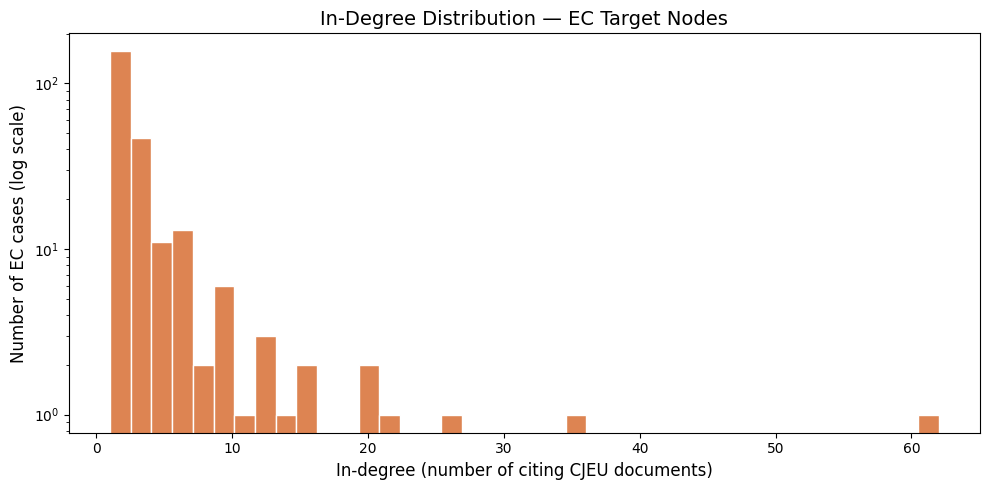

Saved fig_cjeu_ec_dist_ec_indegree.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
ax.hist(ec_in_degree_series, bins=40, color=COLOR_EC, edgecolor="white")
ax.set_yscale("log")
ax.set_title("In-Degree Distribution — EC Target Nodes", fontsize=14, color="black")
ax.set_xlabel("In-degree (number of citing CJEU documents)", fontsize=12, color="black")
ax.set_ylabel("Number of EC cases (log scale)", fontsize=12, color="black")
ax.tick_params(colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_dist_ec_indegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_dist_ec_indegree.png")

### 12A-2. Out-Degree Distribution (CJEU Source Nodes)

Distribution of out-degree across all CJEU source nodes. Shows how many EC cases each
CJEU document cites; most documents cite only a few EC cases, while some cite many.

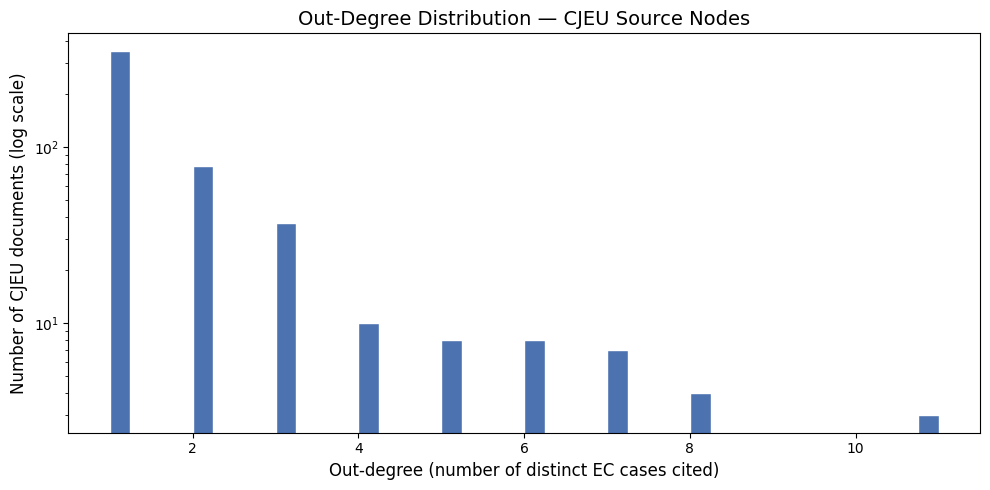

Saved fig_cjeu_ec_dist_cjeu_outdegree.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
ax.hist(cjeu_out_degree_series, bins=40, color=COLOR_CJEU, edgecolor="white")
ax.set_yscale("log")
ax.set_title("Out-Degree Distribution — CJEU Source Nodes", fontsize=14, color="black")
ax.set_xlabel("Out-degree (number of distinct EC cases cited)", fontsize=12, color="black")
ax.set_ylabel("Number of CJEU documents (log scale)", fontsize=12, color="black")
ax.tick_params(colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_dist_cjeu_outdegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_dist_cjeu_outdegree.png")

### 12A-3. PageRank Distribution

Distribution of PageRank scores, shown separately for EC target nodes and CJEU source nodes.
PageRank distributions are typically extremely right-skewed; log y-axis is used for readability.

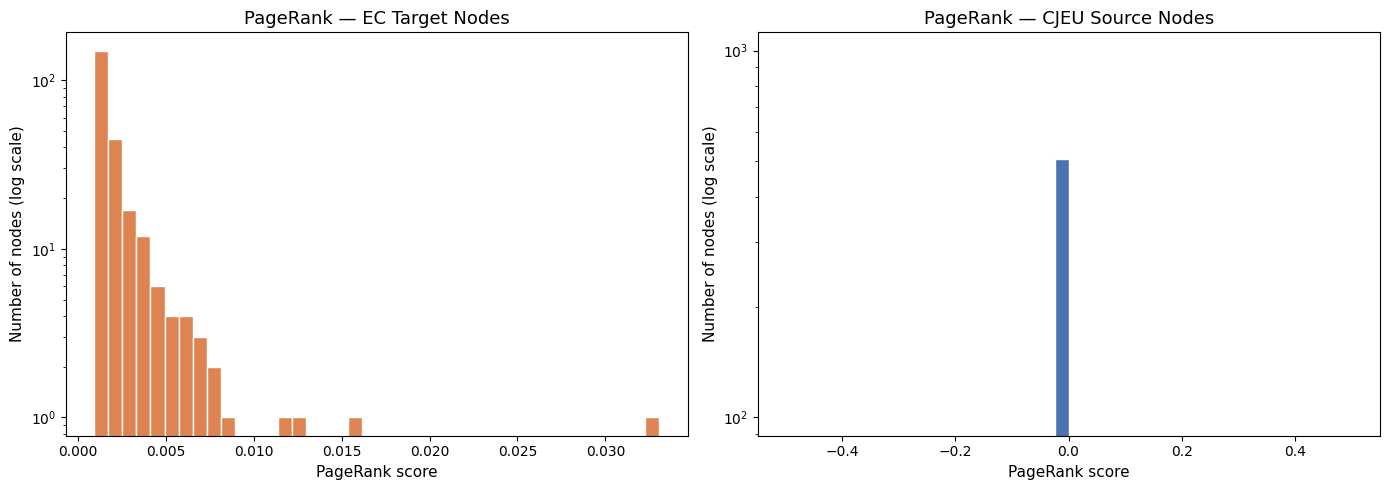

Saved fig_cjeu_ec_dist_pagerank.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

for ax, series, color, title in [
    (axes[0], ec_pagerank_series,   COLOR_EC,   "PageRank — EC Target Nodes"),
    (axes[1], cjeu_pagerank_series, COLOR_CJEU, "PageRank — CJEU Source Nodes"),
]:
    ax.set_facecolor("white")
    ax.hist(series, bins=40, color=color, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, color="black")
    ax.set_xlabel("PageRank score", fontsize=11, color="black")
    ax.set_ylabel("Number of nodes (log scale)", fontsize=11, color="black")
    ax.tick_params(colors="black")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_dist_pagerank.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_dist_pagerank.png")

---
## 13. Summary Tables

### 13A. Top Cited EC Cases

Ranked by **in-degree** (raw citation count), also showing **PageRank** (prestige-weighted score).
These are the EC antitrust cases most frequently referenced by CJEU documents.

In [23]:
top_ec_cited = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values(["in_degree", "pagerank"], ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most cited EC cases (ranked by in-degree, then PageRank):")
display(top_ec_cited.head(30))

Top 30 most cited EC cases (ranked by in-degree, then PageRank):


,case_number,label,in_degree,pagerank
0,IV/31149,POLYPROPYLENE,62,0.033064
1,IV/31865,PVC,35,0.015453
2,AT.35691,Pre-insulated pipe cartel,26,0.011556
3,IV/31553,Welded Steel Mesh,21,0.012915
4,IV/3344; IV/4,Grundig-Consten,20,0.006818
5,IV/4,GRUNDIG,20,0.006818
6,AT.34466,Greek Ferries,16,0.007776
7,IV/33133,Soda-ash - ICI,15,0.008757
8,AT.35814,Extra d'alliage,14,0.007554
9,AT.36545,PO/Amino acids,13,0.005334


### 13B. Top Citing CJEU Documents

Ranked by **out-degree** (number of distinct EC cases cited).
These are the CJEU documents that draw most heavily on EC antitrust precedents.

In [24]:
top_cjeu_citing = (
    cjeu_nodes.set_index("node_id")[["celex_id", "label", "date"]]
    .assign(
        out_degree=lambda df: df.index.map(out_degree_all),
    )
    .sort_values("out_degree", ascending=False)
    .reset_index(drop=True)
)
top_cjeu_citing["display_label"] = top_cjeu_citing.apply(_make_cjeu_label, axis=1)

print("Top 30 most citing CJEU documents (ranked by out-degree):")
display(top_cjeu_citing[["display_label", "celex_id", "out_degree", "date"]].head(30))


Top 30 most citing CJEU documents (ranked by out-degree):


,display_label,celex_id,out_degree,date
0,T-191/98,61998TJ0191,11,2003-09-30
1,T-19/91,61991TJ0019,11,1992-02-27
2,T-228/97,61997TJ0228,11,1999-10-07
3,T-38/02,62002TJ0038,8,2005-10-25
4,T-213/95,61995TJ0213,8,1997-10-22
5,T-24/93,61993TJ0024,8,1996-10-08
6,T-224/00,62000TJ0224,8,2003-07-09
7,T-213/00,62000TJ0213,7,2003-03-19
8,C-125/07,62007CC0125,7,2009-03-26
9,T-325/01,62001TJ0325,7,2005-09-15


---
## 13C. Top 10 Cited EC Cases by In-Degree

This horizontal bar chart shows the ten EC antitrust cases most frequently cited by CJEU documents,
ranked by in-degree (raw citation count). These are the most referenced EC precedents in the network.

[Consistency] EC In-Degree Top-10: nodes=10, missing label before fallback=0, after fallback=0, plotting=10


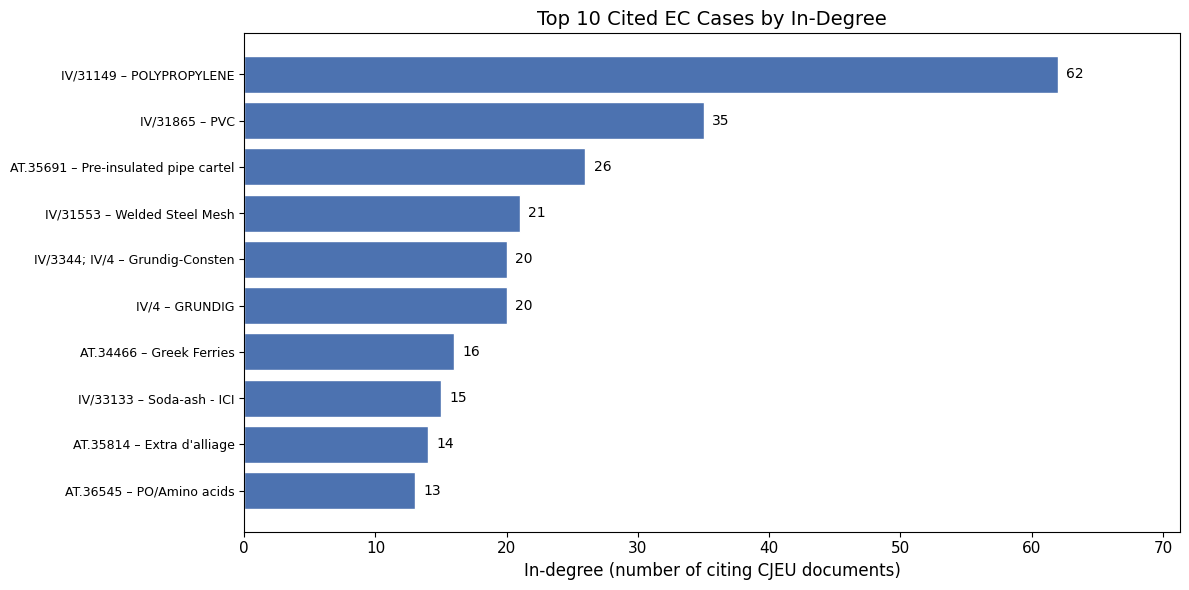

Saved fig_cjeu_ec_top10_ec_indegree.png


In [25]:
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})

# Step 1: rank ALL nodes by metric, then take top 10
top10_ec_indeg = (
    ec_nodes.set_index("node_id")[["case_number", "label", "celex_no"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Step 2: build fallback label AFTER selecting top 10
def _make_ec_label(r):
    cn  = str(r.get("case_number", "")).strip()
    lbl = str(r.get("label", "")).strip()
    cx  = str(r.get("celex_no", "")).strip()
    if cn and lbl:
        return f"{cn} – {lbl[:60]}"
    elif cn:
        return cn
    elif cx:
        return cx
    else:
        return str(r.name)

top10_ec_indeg["bar_label"] = top10_ec_indeg.apply(_make_ec_label, axis=1)

# Consistency check
_n_missing_before = top10_ec_indeg["case_number"].str.strip().eq("").sum()
_n_missing_after  = top10_ec_indeg["bar_label"].str.strip().eq("").sum()
print(f"[Consistency] EC In-Degree Top-10: nodes={len(top10_ec_indeg)}, missing label before fallback={_n_missing_before}, after fallback={_n_missing_after}, plotting={'10' if len(top10_ec_indeg)==10 else str(len(top10_ec_indeg))+' (< 10!)'}")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_ec_indeg["in_degree"].max()
bars = ax.barh(top10_ec_indeg["bar_label"][::-1], top10_ec_indeg["in_degree"][::-1],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_ec_indeg["in_degree"][::-1]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 Cited EC Cases by In-Degree", fontsize=14, color="black")
ax.set_xlabel("In-degree (number of citing CJEU documents)", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_top10_ec_indegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_top10_ec_indegree.png")

### 13D. Top 10 Citing CJEU Documents by Out-Degree

This horizontal bar chart shows the ten CJEU documents that cite the most distinct EC antitrust cases,
ranked by out-degree. These are the CJEU judgments most heavily drawing on EC antitrust precedents.

[Consistency] CJEU Out-Degree Top-10: nodes=10, existing_cn=0, derived_cn=10, celex_fallback=0, nodeid_fallback=0, plotting=10


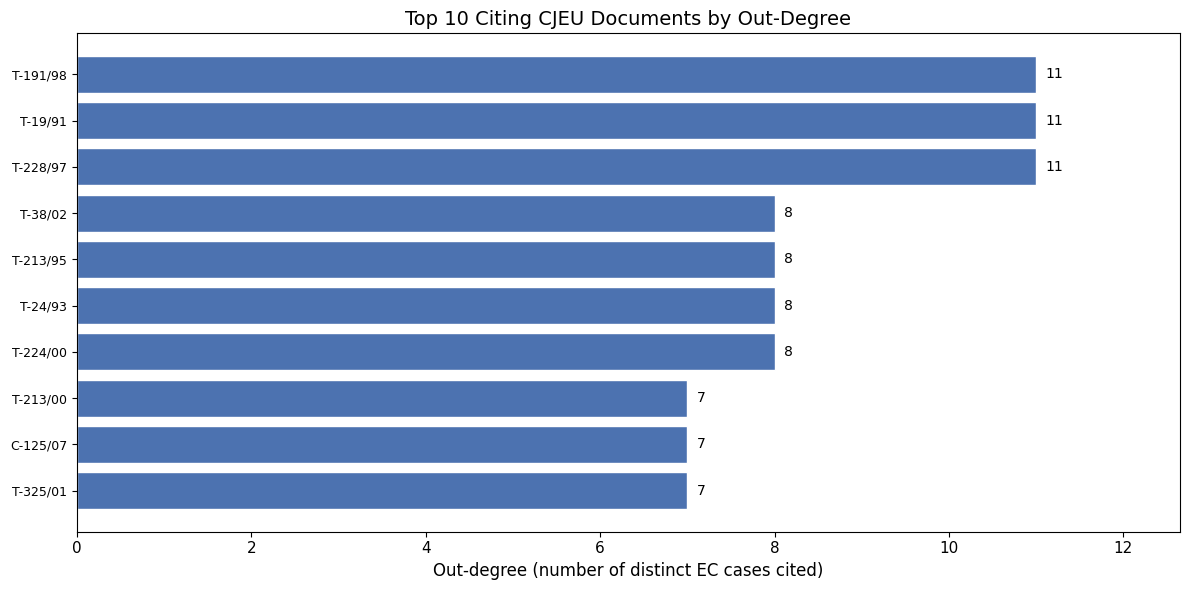

Saved fig_cjeu_ec_top10_cjeu_outdegree.png


In [26]:
# Step 1: rank ALL nodes by metric, then take top 10
top10_cjeu_outdeg = (
    cjeu_nodes.set_index("node_id")[["celex_id", "label", "date"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Step 2: build fallback label AFTER selecting top 10 (uses _make_cjeu_label defined above)

top10_cjeu_outdeg["bar_label"] = top10_cjeu_outdeg.apply(_make_cjeu_label, axis=1)

# Consistency check
_n_existing_cn = sum(1 for _, r in top10_cjeu_outdeg.iterrows()
                     if str(r.get("label","")).strip() and not str(r.get("label","")).strip().startswith("6")
                     and str(r.get("label","")).strip() != str(r.get("celex_id","")).strip())
_n_derived_cn  = sum(1 for _, r in top10_cjeu_outdeg.iterrows()
                     if not (str(r.get("label","")).strip() and not str(r.get("label","")).strip().startswith("6")
                             and str(r.get("label","")).strip() != str(r.get("celex_id","")).strip())
                     and bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())))
_n_celex_fb    = sum(1 for _, r in top10_cjeu_outdeg.iterrows()
                     if not (str(r.get("label","")).strip() and not str(r.get("label","")).strip().startswith("6")
                             and str(r.get("label","")).strip() != str(r.get("celex_id","")).strip())
                     and not _derive_case_number_from_celex(str(r.get("celex_id","")).strip())
                     and str(r.get("celex_id","")).strip())
_n_nodeid_fb   = len(top10_cjeu_outdeg) - _n_existing_cn - _n_derived_cn - _n_celex_fb
print(f"[Consistency] CJEU Out-Degree Top-10: nodes={len(top10_cjeu_outdeg)}, "
      f"existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, "
      f"celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, "
      f"plotting={'10' if len(top10_cjeu_outdeg)==10 else str(len(top10_cjeu_outdeg))+' (< 10!)'}")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_cjeu_outdeg["out_degree"].max()
bars = ax.barh(top10_cjeu_outdeg["bar_label"][::-1], top10_cjeu_outdeg["out_degree"][::-1],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_cjeu_outdeg["out_degree"][::-1]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 Citing CJEU Documents by Out-Degree", fontsize=14, color="black")
ax.set_xlabel("Out-degree (number of distinct EC cases cited)", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_top10_cjeu_outdegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_top10_cjeu_outdegree.png")


### 13E. Top 10 EC Cases by PageRank

This horizontal bar chart shows the ten EC antitrust cases with the highest PageRank score in the
CJEU → EC citation network. PageRank accounts for the prestige of citing documents, so cases cited
by influential CJEU judgments rank higher than those with merely many citations.

[Consistency] EC PageRank Top-10: nodes=10, missing label before fallback=0, after fallback=0, plotting=10


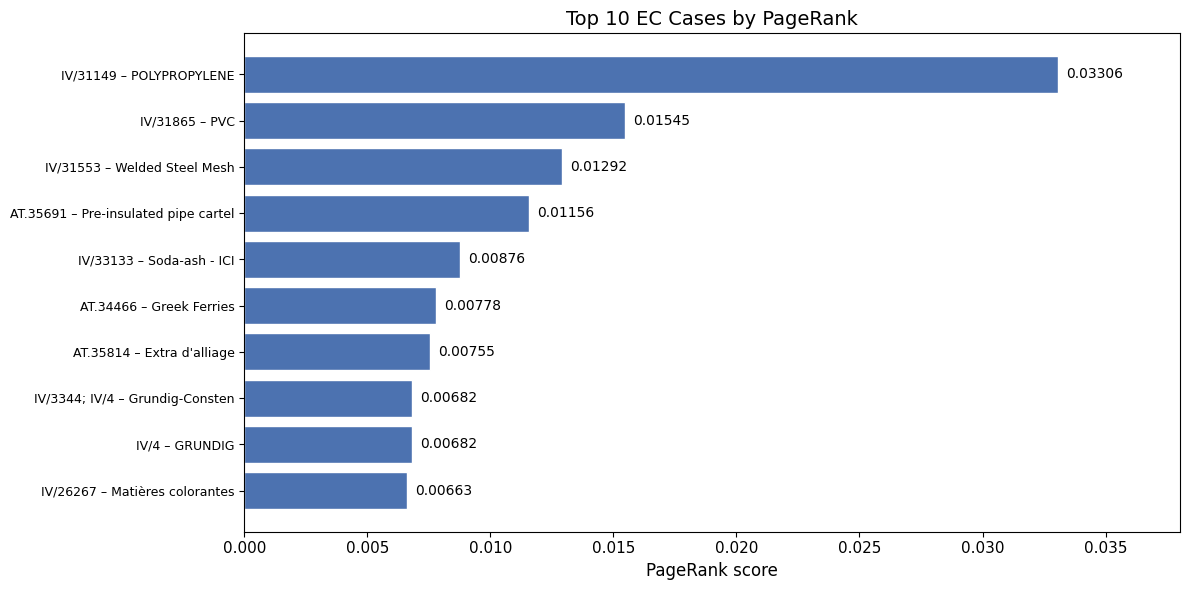

Saved fig_cjeu_ec_top10_ec_pagerank.png


In [27]:
# Step 1: rank ALL nodes by metric, then take top 10
top10_ec_pr = (
    ec_nodes.set_index("node_id")[["case_number", "label", "celex_no"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Step 2: build fallback label AFTER selecting top 10
top10_ec_pr["bar_label"] = top10_ec_pr.apply(_make_ec_label, axis=1)

# Consistency check
_n_missing_before = top10_ec_pr["case_number"].str.strip().eq("").sum()
_n_missing_after  = top10_ec_pr["bar_label"].str.strip().eq("").sum()
print(f"[Consistency] EC PageRank Top-10: nodes={len(top10_ec_pr)}, missing label before fallback={_n_missing_before}, after fallback={_n_missing_after}, plotting={'10' if len(top10_ec_pr)==10 else str(len(top10_ec_pr))+' (< 10!'}")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_ec_pr["pagerank"].max()
bars = ax.barh(top10_ec_pr["bar_label"][::-1], top10_ec_pr["pagerank"][::-1],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_ec_pr["pagerank"][::-1]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 EC Cases by PageRank", fontsize=14, color="black")
ax.set_xlabel("PageRank score", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_ec_top10_ec_pagerank.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved fig_cjeu_ec_top10_ec_pagerank.png")

---
## 14. Export

In [28]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Node and edge tables
all_nodes.to_csv(NODES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(all_nodes):,} nodes to: {NODES_PATH}")

edges.to_csv(EDGES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(edges):,} edges to: {EDGES_PATH}")

# GraphML
nx.write_graphml(G, str(GRAPHML_PATH))
print(f"Saved GraphML to: {GRAPHML_PATH}")

# GEXF with Gephi-compatible viz colours
GEXF_PATH = OUT_DIR / "cjeu_ec_network.gexf"
for node in G.nodes():
    if G.nodes[node].get("node_type") == "cjeu":
        G.nodes[node]["viz"] = {"color": {"r": 76, "g": 114, "b": 176, "a": 1.0}}
    elif G.nodes[node].get("node_type") == "ec":
        G.nodes[node]["viz"] = {"color": {"r": 221, "g": 132, "b": 82, "a": 1.0}}
nx.write_gexf(G, str(GEXF_PATH))
print(f"Saved GEXF  to: {GEXF_PATH}")

# Node metrics
node_metrics.to_csv(NODE_METRICS_PATH, index=False, encoding="utf-8")
print(f"Saved node metrics to: {NODE_METRICS_PATH}")


Saved 753 nodes to: data\processed\network\cjeu_ec\cjeu_ec_nodes.csv
Saved 859 edges to: data\processed\network\cjeu_ec\cjeu_ec_edges.csv
Saved GraphML to: data\processed\network\cjeu_ec\cjeu_ec_network.graphml
Saved GEXF  to: data\processed\network\cjeu_ec\cjeu_ec_network.gexf
Saved node metrics to: data\processed\network\cjeu_ec\cjeu_ec_node_metrics.csv
